In [2]:
# import pandas as pd
import xarray as xr 
from dask_jobqueue import SLURMCluster

cluster = SLURMCluster(
    job_name="Climt1",          # --job-name
    cores=12,                   # 24 cores per node
    processes=4,                # One process per task
    memory="100GB",             # --mem
    walltime="00:30:00",        # --time
    queue="short",                # --partition
    log_directory=".",          # Logs will be saved to the current directory
)

/home1/nalex2023/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45455 instead
  warnings.warn(


In [3]:
from dask.distributed import Client
import numpy as np

cluster.scale(jobs=2)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.26.1.1:45455/status,
Dashboard: http://172.26.1.1:45455/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.26.1.1:44887,Workers: 0
Dashboard: http://172.26.1.1:45455/status,Total threads: 0
Started: Just now,Total memory: 0 B


## Load ~8 months of surface datasets 



In [5]:
import pandas as pd

In [6]:
twp_manus = '/home2/nalex2023/Datasets/LSB_OUTS/met_manus_30min/'

sun_dft = pd.read_csv('/home1/nalex2023/main/LSB_main/LSB_detectionv2/Datasets/sunrise_sunset_twp.csv')

sun_dft = sun_dft.map(pd.to_datetime)

sun_dft['sunrise_local'] = sun_dft['sunrise(UTC)'] + pd.Timedelta(hours=10)

sun_dft['sunset_local'] = sun_dft['sunset(UTC)'] + pd.Timedelta(hours=10)

wind_speed_ds = xr.open_mfdataset(twp_manus+"*.nc")


wind_speed_data = wind_speed_ds.roll(time=10*2,roll_coords=False).sel(time=slice('2011-11','2012-06'))
wind_speed_data['atmos_pressure'] = wind_speed_data['atmos_pressure'] * 10

sun_dft = sun_dft[(sun_dft['date'] >='2011-11') & (sun_dft['date'] <= '2012-06')]


/home1/nalex2023/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


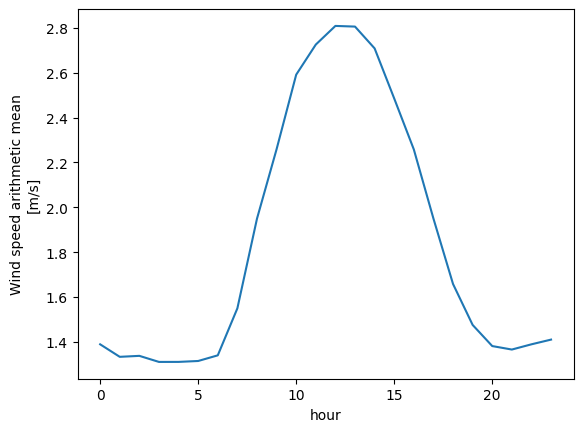

In [7]:

wind_speed_data['wspd_arith_mean'].groupby('time.hour').mean().plot()

In [8]:
sun_dft

,date,sunrise(UTC),sunset(UTC),sunrise_local,sunset_local
4322,2011-11-01,2011-10-31 19:48:19.825672192,2011-11-01 07:59:28.507674880,2011-11-01 05:48:19.825672192,2011-11-01 17:59:28.507674880
4323,2011-11-02,2011-11-01 19:48:15.519057152,2011-11-02 07:59:30.283845888,2011-11-02 05:48:15.519057152,2011-11-02 17:59:30.283845888
4324,2011-11-03,2011-11-02 19:48:12.027247872,2011-11-03 07:59:32.820392448,2011-11-03 05:48:12.027247872,2011-11-03 17:59:32.820392448
4325,2011-11-04,2011-11-03 19:48:09.360754432,2011-11-04 07:59:36.124693248,2011-11-04 05:48:09.360754432,2011-11-04 17:59:36.124693248
4326,2011-11-05,2011-11-04 19:48:07.529913600,2011-11-05 07:59:40.204086016,2011-11-05 05:48:07.529913600,2011-11-05 17:59:40.204086016
...,...,...,...,...,...
4531,2012-05-28,2012-05-27 20:07:22.182466816,2012-05-28 08:07:57.406294016,2012-05-28 06:07:22.182466816,2012-05-28 18:07:57.406294016
4532,2012-05-29,2012-05-28 20:07:31.551522048,2012-05-29 08:08:03.966512128,2012-05-29 06:07:31.551522048,2012-05-29 18:08:03.966512128
4533,2012-05-30,2012-05-29 20:07:41.275235072,2012-05-30 08:08:10.992589824,2012-05-30 06:07:41.275235072,2012-05-30 18:08:10.992589824
4534,2012-05-31,2012-05-30 20:07:51.339734016,2012-05-31 08:08:18.471296768,2012-05-31 06:07:51.339734016,2012-05-31 18:08:18.471296768


# Load the final wind speed dataset

In [9]:
import matplotlib.pyplot as plt

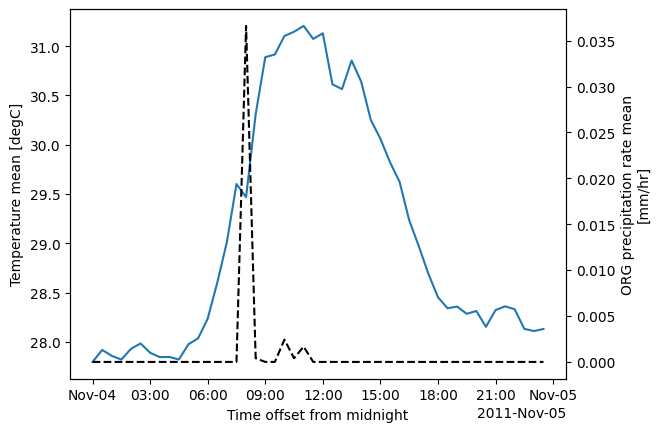

In [10]:
fig,ax = plt.subplots()
wind_speed_data['temp_mean'].sel(time='2011-11-04').plot(ax=ax)
ax2 = ax.twinx()
wind_speed_data['org_precip_rate_mean'].sel(time='2011-11-04').plot(ax=ax2,linestyle='--',color='black')

# Applying the sunset and sunrise to filter times 


In [12]:
wind_speed_data = wind_speed_data.compute()



In [11]:
# filter 1 application
import numpy as np

wind_speed_data['sunrise_local'] = xr.DataArray(sun_dft['sunrise_local'].values,dims=('day'),
                      coords={'day':sun_dft['date']},name='sunrise_local')

wind_speed_data['sunset_local'] = xr.DataArray(sun_dft['sunset_local'].values,dims=('day'),
                      coords={'day':sun_dft['date']},name='sunset_local')

wind_speed_data['day_str'] = wind_speed_data['day'].dt.date.astype(str)

#sunrise = wind_speed_data['sunrise_utc'].isel(day=0).values +pd.Timedelta(hours=10)
all_days_mpoi = []
all_days_mpoc = []
for ii in wind_speed_data['day']:
    sunrise = wind_speed_data.sel(day=ii)['sunrise_local']
    sunset = wind_speed_data.sel(day=ii)['sunset_local']
    start = sunrise + pd.Timedelta(hours=1)
    end = sunrise + pd.Timedelta(hours=7)
    date_sunrise = str(sunrise.dt.date.values)
    that_day = wind_speed_data.sel(time=date_sunrise)
    that_day['mpoi'] = xr.where(
    (that_day.time >= start.values) & (that_day.time <= end.values),
    1,
    0
)
    all_days_mpoi += [that_day['mpoi']]
    
    cess_start = sunset + pd.Timedelta(hours=-1)
    cess_end = sunset + pd.Timedelta(hours=5)

    that_day['mpoc'] = xr.where(
    (that_day.time >= cess_start.values) & (that_day.time <= cess_end.values),
    1,
    0
)

    all_days_mpoc += [that_day['mpoc']]
   




In [12]:
wind_speed_data['mpoi'] = xr.concat(all_days_mpoi,dim='time')
wind_speed_data['mpoc'] = xr.concat(all_days_mpoc,dim='time')

In [13]:
wind_speed_data

<xarray.Dataset> Size: 620kB
Dimensions:               (time: 11664, day: 214)
Coordinates:
  * time                  (time) datetime64[ns] 93kB 2011-11-01 ... 2012-06-3...
  * day                   (day) datetime64[ns] 2kB 2011-11-01 ... 2012-06-01
Data variables:
    atmos_pressure        (time) float32 47kB 1.007e+03 1.006e+03 ... 1.009e+03
    temp_mean             (time) float32 47kB 28.23 28.19 28.16 ... 26.44 26.64
    rh_mean               (time) float32 47kB 75.06 74.5 74.37 ... 84.13 82.88
    wspd_arith_mean       (time) float32 47kB 1.14 1.032 1.173 ... 2.53 2.447
    wspd_vec_mean         (time) float32 47kB 1.031 0.9597 1.078 ... 2.515 2.426
    wdir_vec_mean         (time) float32 47kB 113.2 192.7 130.0 ... 161.2 153.5
    org_precip_rate_mean  (time) float32 47kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sunrise_local         (day) datetime64[ns] 2kB 2011-11-01T05:48:19.825672...
    sunset_local          (day) datetime64[ns] 2kB 2011-11-01T17:59:28.507674...
    day_str               (day) <U10 9kB '2011-11-01' ... '2012-06-01'
    mpoi                  (time) float64 93kB 0.0 0.0 0.0 0.0 ... nan nan nan
    mpoc                  (time) float64 93kB 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes: (12/30)
    command_line:                met_ingest -s twp -f C1 -R
    process_version:             ingest-met-4.28-0.el6
    dod_version:                 met-b1-8.1
    input_source:                /data/home/gervais/prod/jobs/0742/collection...
    site_id:                     twp
    platform_id:                 met
    ...                          ...
    qc_bit_2_assessment:         Bad
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    history:                     created by user gervais on machine amber at ...

In [14]:


start = '2011-11-01'
end = '2012-06-01'

def detect_lsb_ws_onset(wind_speed_data: xr.Dataset, day: pd.Timestamp) -> str:
    test_day = str(pd.to_datetime(day).date())
    try:
        sunrise = wind_speed_data['sunrise_local'].sel(day=test_day).values 
    except KeyError:
        return np.nan
    sunrise_range = pd.date_range(start=sunrise+pd.Timedelta(hours=1),end=sunrise+pd.Timedelta(hours=7),freq="30min").round("30min")
    post_sunrise_data = wind_speed_data.sel(time=sunrise_range)
    if post_sunrise_data.time.size == 0:
        return np.nan
    diff_data = post_sunrise_data["wspd_arith_mean"].diff(dim="time").reindex(time=post_sunrise_data["time"])
    lsb_ws_onset = post_sunrise_data["wspd_arith_mean"][diff_data > 0.5]
    return lsb_ws_onset.time[0].dt.time.astype(str).values if lsb_ws_onset.size > 0 else np.nan

filter_1_results = pd.date_range(start=start,end=end,freq='1D').to_series()


test_result_dft = pd.DataFrame(filter_1_results,columns=['datetime'])
test_result_dft['filter2_wspd']= filter_1_results.apply(lambda d: detect_lsb_ws_onset(wind_speed_data,d))




In [15]:
test_result_dft['filter2'] = ~test_result_dft['filter2_wspd'].isna()


In [16]:
test_result_dft

,datetime,filter2_wspd,filter2
2011-11-01,2011-11-01,08:00:00,True
2011-11-02,2011-11-02,10:30:00,True
2011-11-03,2011-11-03,NaN,False
2011-11-04,2011-11-04,NaN,False
2011-11-05,2011-11-05,09:00:00,True
...,...,...,...
2012-05-28,2012-05-28,07:30:00,True
2012-05-29,2012-05-29,08:30:00,True
2012-05-30,2012-05-30,10:30:00,True
2012-05-31,2012-05-31,08:00:00,True


In [17]:
def detect_lsb_wd_condition(wind_speed_data: xr.Dataset, day: pd.Timestamp) -> str:
    min_wd = 0
    max_wd = 180
    test_day = str(pd.to_datetime(day).date())
    try:
        sunrise = wind_speed_data['sunrise_local'].sel(day=test_day).values
    except KeyError:
        return np.nan
    sunrise_range = pd.date_range(start=sunrise+pd.Timedelta(hours=1),end=sunrise+pd.Timedelta(hours=7),freq="30min").round("30min")
    post_sunrise_data = wind_speed_data.sel(time=sunrise_range)
    if post_sunrise_data.time.size == 0:
        return np.nan
    wd_mask = (post_sunrise_data["wdir_vec_mean"] >= min_wd) & (post_sunrise_data["wdir_vec_mean"] <= max_wd)
    lsb_ws_onset = post_sunrise_data["wdir_vec_mean"][wd_mask]
    return lsb_ws_onset.time[0].dt.time.astype(str).values if lsb_ws_onset.size > 0 else np.nan

test_result_dft['filter3_wdir']= filter_1_results.apply(lambda d: detect_lsb_wd_condition(wind_speed_data,d))

In [18]:
test_result_dft['filter3_result'] = ~test_result_dft['filter3_wdir'].isna()

test_result_dft

,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True
2011-11-03,2011-11-03,NaN,False,07:00:00,True
2011-11-04,2011-11-04,NaN,False,08:30:00,True
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True
...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True
2012-05-31,2012-05-31,08:00:00,True,NaN,False


In [19]:


def filter4_prev_cond(wind_speed_data: xr.Dataset,result_dft:pd.Series) -> bool:
    input_data = result_dft
    time_onset = input_data['datetime'].strftime("%Y-%m-%d") + ' ' +input_data['filter2_wspd']
    test_time = pd.to_datetime(time_onset) - pd.Timedelta(minutes=30)

    wspd_diff = wind_speed_data['wspd_arith_mean'].diff(dim='time')

    wd_prev = wind_speed_data['wspd_vec_mean'].sel(time=test_time)
    ws_diff_prev = wspd_diff.sel(time=test_time)
    
    if ws_diff_prev < 1.5:
        condition1 = True
    else :
        condition1 = False

    if (wd_prev > 181):
        condition2 = True
    else:
        condition2 = False

    return (condition1 or condition2)


test_result_dft_notna = test_result_dft[test_result_dft['filter2'] == True]


test_result_dft["filter4_prev_wind"] = test_result_dft_notna.apply(lambda row: filter4_prev_cond(wind_speed_data, row), axis=1).reindex(test_result_dft.index,
                                                                                                                                                    fill_value=np.nan)


test_result_dft

,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result,filter4_prev_wind
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True,True
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True,True
2011-11-03,2011-11-03,NaN,False,07:00:00,True,NaN
2011-11-04,2011-11-04,NaN,False,08:30:00,True,NaN
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True,True
...,...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False,True
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True,True
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True,True
2012-05-31,2012-05-31,08:00:00,True,NaN,False,True


In [20]:
test_result_dft['filter4_prev_wind'] = test_result_dft['filter4_prev_wind'].fillna(False)

/tmp/ipykernel_2672088/3577022563.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_result_dft['filter4_prev_wind'] = test_result_dft['filter4_prev_wind'].fillna(False)


In [21]:
wind_speed_data.sel(time='2011-11-01')['wspd_arith_mean'].max()

<xarray.DataArray 'wspd_arith_mean' ()> Size: 4B
array(3.7192667, dtype=float32)

In [22]:
def detect_lsb_ws_cess(wind_speed_data: xr.Dataset, day: pd.Series) -> bool:
    test_day = str(pd.to_datetime(day).date())
    try:
        sunset = wind_speed_data['sunset_local'].sel(day=test_day).values
    except KeyError:
        return np.nan
    sunset_range = pd.date_range(start=sunset+pd.Timedelta(hours=-1),end=sunset+pd.Timedelta(hours=+5),freq="30min").round("30min")
    post_sunset_data = wind_speed_data.sel(time=sunset_range)
    if post_sunset_data.time.size == 0:
        return np.nan
    max_sea = post_sunset_data["wspd_arith_mean"].max()
    time_max = post_sunset_data["wspd_arith_mean"].idxmax()
    return time_max.dt.time.astype(str).values if max_sea < 2.5 else np.nan

test_result_dft['filter6_wsmax']= filter_1_results.apply(lambda d: detect_lsb_ws_cess(wind_speed_data,d))


test_result_dft

,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result,filter4_prev_wind,filter6_wsmax
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True,True,NaN
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True,True,17:00:00
2011-11-03,2011-11-03,NaN,False,07:00:00,True,False,21:00:00
2011-11-04,2011-11-04,NaN,False,08:30:00,True,False,17:00:00
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True,True,20:30:00
...,...,...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False,True,NaN
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True,True,NaN
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True,True,17:00:00
2012-05-31,2012-05-31,08:00:00,True,NaN,False,True,NaN


In [23]:
test_result_dft['filter_6'] = ~test_result_dft['filter6_wsmax'].isna()

In [24]:
test_result_dft

,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result,filter4_prev_wind,filter6_wsmax,filter_6
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True,True,NaN,False
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True,True,17:00:00,True
2011-11-03,2011-11-03,NaN,False,07:00:00,True,False,21:00:00,True
2011-11-04,2011-11-04,NaN,False,08:30:00,True,False,17:00:00,True
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True,True,20:30:00,True
...,...,...,...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False,True,NaN,False
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True,True,NaN,False
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True,True,17:00:00,True
2012-05-31,2012-05-31,08:00:00,True,NaN,False,True,NaN,False


In [25]:
def synop_filter7(wind_speed_data: xr.Dataset, day: pd.Timestamp) -> str:
    test_day = str(pd.to_datetime(day).date())
    try:
        sunrise = wind_speed_data['sunrise_local'].sel(day=test_day).values 
    except KeyError:
        return np.nan
    sunrise_range = pd.date_range(start=sunrise+pd.Timedelta(hours=1),end=sunrise+pd.Timedelta(hours=7),freq="30min").round("30min")
    post_sunrise_data = wind_speed_data.sel(time=sunrise_range)
    if post_sunrise_data.time.size == 0:
        return np.nan
    max_data = post_sunrise_data['wspd_arith_mean'].max()
    return True if max_data < 6 else False


test_result_dft['filter7_synop']= filter_1_results.apply(lambda d: synop_filter7(wind_speed_data,d))

test_result_dft


,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result,filter4_prev_wind,filter6_wsmax,filter_6,filter7_synop
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True,True,NaN,False,True
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True,True,17:00:00,True,True
2011-11-03,2011-11-03,NaN,False,07:00:00,True,False,21:00:00,True,True
2011-11-04,2011-11-04,NaN,False,08:30:00,True,False,17:00:00,True,True
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True,True,20:30:00,True,True
...,...,...,...,...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False,True,NaN,False,True
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True,True,NaN,False,True
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True,True,17:00:00,True,True
2012-05-31,2012-05-31,08:00:00,True,NaN,False,True,NaN,False,True


In [26]:
wind_speed_data

<xarray.Dataset> Size: 620kB
Dimensions:               (time: 11664, day: 214)
Coordinates:
  * time                  (time) datetime64[ns] 93kB 2011-11-01 ... 2012-06-3...
  * day                   (day) datetime64[ns] 2kB 2011-11-01 ... 2012-06-01
Data variables:
    atmos_pressure        (time) float32 47kB 1.007e+03 1.006e+03 ... 1.009e+03
    temp_mean             (time) float32 47kB 28.23 28.19 28.16 ... 26.44 26.64
    rh_mean               (time) float32 47kB 75.06 74.5 74.37 ... 84.13 82.88
    wspd_arith_mean       (time) float32 47kB 1.14 1.032 1.173 ... 2.53 2.447
    wspd_vec_mean         (time) float32 47kB 1.031 0.9597 1.078 ... 2.515 2.426
    wdir_vec_mean         (time) float32 47kB 113.2 192.7 130.0 ... 161.2 153.5
    org_precip_rate_mean  (time) float32 47kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sunrise_local         (day) datetime64[ns] 2kB 2011-11-01T05:48:19.825672...
    sunset_local          (day) datetime64[ns] 2kB 2011-11-01T17:59:28.507674...
    day_str               (day) <U10 9kB '2011-11-01' ... '2012-06-01'
    mpoi                  (time) float64 93kB 0.0 0.0 0.0 0.0 ... nan nan nan
    mpoc                  (time) float64 93kB 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes: (12/30)
    command_line:                met_ingest -s twp -f C1 -R
    process_version:             ingest-met-4.28-0.el6
    dod_version:                 met-b1-8.1
    input_source:                /data/home/gervais/prod/jobs/0742/collection...
    site_id:                     twp
    platform_id:                 met
    ...                          ...
    qc_bit_2_assessment:         Bad
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    history:                     created by user gervais on machine amber at ...

In [27]:
def filter8_pres(wind_speed_data: xr.Dataset, input_data: pd.Series):
    onset_time = input_data['filter2_wspd']
    cess_time = input_data['filter6_wsmax']

    if pd.isna(onset_time) or pd.isna(cess_time):
        return np.nan

    date_str = pd.to_datetime(input_data.name).strftime("%Y-%m-%d")
    time_onset = pd.to_datetime(date_str + ' ' + str(onset_time))
    time_cess = pd.to_datetime(date_str + ' ' + str(cess_time))

    pres_cess = wind_speed_data['atmos_pressure'].sel(time=time_cess).item()
    min_pres = wind_speed_data['atmos_pressure'].sel(time=slice(time_onset, time_cess)).min().item()

    return (pres_cess - min_pres) <= 1



test_result_dft["filter8_pres"] = test_result_dft.apply(lambda row: filter8_pres(wind_speed_data, row), axis=1).reindex(test_result_dft.index,
                                                                                                                                                    fill_value=np.nan)


test_result_dft

,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result,filter4_prev_wind,filter6_wsmax,filter_6,filter7_synop,filter8_pres
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True,True,NaN,False,True,NaN
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True,True,17:00:00,True,True,True
2011-11-03,2011-11-03,NaN,False,07:00:00,True,False,21:00:00,True,True,NaN
2011-11-04,2011-11-04,NaN,False,08:30:00,True,False,17:00:00,True,True,NaN
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True,True,20:30:00,True,True,False
...,...,...,...,...,...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False,True,NaN,False,True,NaN
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True,True,NaN,False,True,NaN
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True,True,17:00:00,True,True,True
2012-05-31,2012-05-31,08:00:00,True,NaN,False,True,NaN,False,True,NaN


In [ ]:

hourly = wind_speed_data['atmos_pressure'].resample(time='1h').mean()

pten = hourly.groupby('time.hour').mean().sel(hour=10)
p22 = hourly.groupby('time.hour').mean().sel(hour=22)
pfour = hourly.groupby('time.hour').mean().sel(hour=4)
p16 = hourly.groupby('time.hour').mean().sel(hour=16)

atide_gen = (pten + p22) - (pfour - p16)


atide_gen.values

array(2017.4575, dtype=float32)

In [ ]:
def filter9_tide(wind_speed_data: xr.Dataset, day: pd.Series):
    test_day = str(pd.to_datetime(day).date())
    time_set = pd.date_range(start=test_day, periods=48, freq='30min')

    atide_gen = 2017.4575
    hourly = wind_speed_data['atmos_pressure'].sel(time=time_set).resample(time='1h').mean()

    pten = hourly.where(hourly.time.dt.hour == 10, drop=True).squeeze().item()
    p22 = hourly.where(hourly.time.dt.hour == 22, drop=True).squeeze().item()
    pfour = hourly.where(hourly.time.dt.hour == 4, drop=True).squeeze().item()
    p16 = hourly.where(hourly.time.dt.hour == 16, drop=True).squeeze().item()

    atide = (pten + p22) - (pfour + p16)

    return (atide - atide_gen) <= -0.5
test_result_dft["filter9_tide"] = filter_1_results.apply(lambda d: filter9_tide(wind_speed_data,d))


test_result_dft

,datetime,filter2_wspd,filter2,filter3_wdir,filter3_result,filter4_prev_wind,filter6_wsmax,filter_6,filter7_synop,filter8_pres,filter9_tide
2011-11-01,2011-11-01,08:00:00,True,08:00:00,True,True,NaN,False,True,NaN,True
2011-11-02,2011-11-02,10:30:00,True,07:00:00,True,True,17:00:00,True,True,True,True
2011-11-03,2011-11-03,NaN,False,07:00:00,True,False,21:00:00,True,True,NaN,True
2011-11-04,2011-11-04,NaN,False,08:30:00,True,False,17:00:00,True,True,NaN,True
2011-11-05,2011-11-05,09:00:00,True,09:00:00,True,True,20:30:00,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
2012-05-28,2012-05-28,07:30:00,True,NaN,False,True,NaN,False,True,NaN,True
2012-05-29,2012-05-29,08:30:00,True,07:00:00,True,True,NaN,False,True,NaN,True
2012-05-30,2012-05-30,10:30:00,True,09:30:00,True,True,17:00:00,True,True,True,True
2012-05-31,2012-05-31,08:00:00,True,NaN,False,True,NaN,False,True,NaN,True


In [14]:
sea_breeze_days = test_result_dft[(test_result_dft['filter2']) & (test_result_dft['filter3_result']) & (test_result_dft['filter4_prev_wind']) & (test_result_dft['filter6_wsmax']) & (test_result_dft['filter7_synop'])]

sea_breeze_days.to_csv('/home1/nalex2023/Datasets/LSB_OUTS/sea_breeze.csv')

NameError: name 'test_result_dft' is not defined

In [13]:
sea_breeze_days

NameError: name 'sea_breeze_days' is not defined

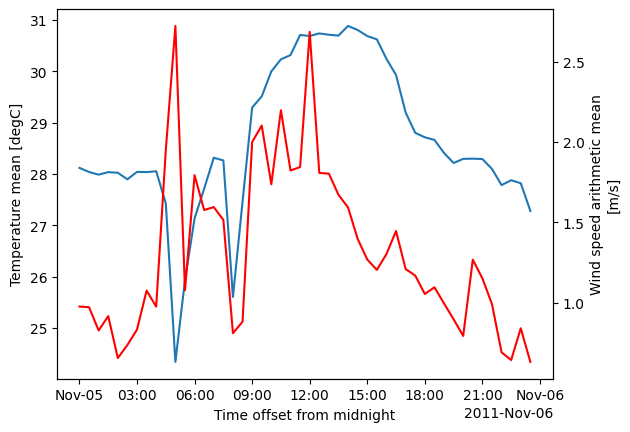

In [56]:
fig,ax = plt.subplots()
wind_speed_data.sel(time='2011-11-05')['temp_mean'].plot(ax=ax)
ax2 = ax.twinx()
wind_speed_data.sel(time='2011-11-05')['wspd_arith_mean'].plot(ax=ax2,color='red')

TypeError: '<' not supported between instances of 'float' and 'datetime.time'

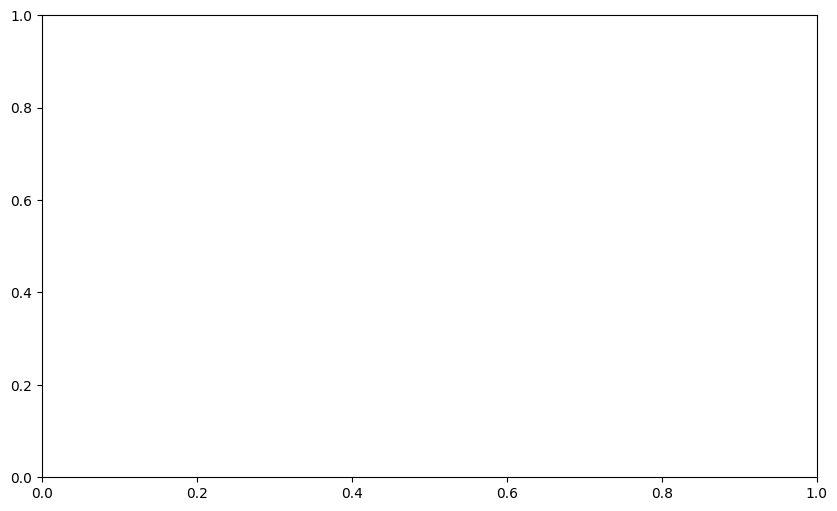

In [4]:
# Create a empty plot with x axis as diurnal as in the format 00:00, 00:30, 01:00, 01:30, ..., 23:30
import matplotlib.pyplot as plt
import pandas as pd
fig, ax = plt.subplots(figsize=(10, 6))
time_range = pd.date_range(start='00:00', end='23:30', freq='30min').time
ax.set_xticks(time_range)